In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

tf.keras.utils.set_random_seed(42)

In [2]:
# Ladda in Fashion MNIST dataset
# https://keras.io/api/datasets/fashion_mnist/
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [3]:
# Storlek och struktur på träningsdata och testdata

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
print("Unika klasser:", np.unique(y_train))

print("Minsta pixelvärde:", X_train.min())
print("Största pixelvärde:", X_train.max())

Unika klasser: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


Vi vill dela upp träningsdatan i träning och validation. Vi använder en test storlek på 10% och vi använder stratify så klassfördelningen blir ungefär lika i träning och validation.

In [5]:
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("X_train", X_train_base.shape)
print("X_val", X_val_base.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [6]:
# Lägga till en kanaldimension

X_train_base = X_train_base[..., np.newaxis]
X_val_base = X_val_base[..., np.newaxis]
X_test_base = X_test[..., np.newaxis]

print("X_train shape efter kanal dimension", X_train_base.shape)
print("X_val shape efter kanal dimension", X_val_base.shape)
print("X_test shape efter kanal dimension", X_test_base.shape)

X_train shape efter kanal dimension (54000, 28, 28, 1)
X_val shape efter kanal dimension (6000, 28, 28, 1)
X_test shape efter kanal dimension (10000, 28, 28, 1)


Varje bild i datasetet har storleken 28 × 28 pixlar. En Convolutional Neural Network (CNN) förväntar sig vanligtvis att inputdata har formen (höjd, bredd, kanaler).

För färgbilder används oftast tre kanaler (röd, grön och blå). Eftersom Fashion MNIST består av gråskalebilder har varje bild endast en kanal.

Därför lägger vi till en extra dimension i datan så att varje bild får formen 28 × 28 × 1. Detta gör att datan får rätt format för CNN-modellen. 

3. Bygg en modell (CNN)

- skapa en första fungerande modell
- använda neurala nätverk (t.ex. CNN)
- säkerställa att modellen kan tränas

In [7]:
# Grundmodell med CNN

def create_model():

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

4) Träna modellen

- träna modellen på träningsdata
- använda validation
- observera hur modellen utvecklas över tid

In [8]:
model_base = create_model()

history_base = model_base.fit(
    X_train_base,
    y_train_base,
    validation_data=(X_val_base, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.8374 - loss: 0.6268 - val_accuracy: 0.8545 - val_loss: 0.3843
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8924 - loss: 0.2976 - val_accuracy: 0.8772 - val_loss: 0.3328
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9074 - loss: 0.2524 - val_accuracy: 0.8888 - val_loss: 0.2985
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9188 - loss: 0.2205 - val_accuracy: 0.8855 - val_loss: 0.3175
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9248 - loss: 0.2021 - val_accuracy: 0.8953 - val_loss: 0.3066


In [9]:
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,704 (2.52 MB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440,470 (1.68 MB)

Vi kompilerar vår baseline-modell med optimeraren Adam och en learning rate på 0.001. Adam används eftersom den är effektiv för de flesta neurala nätverk och anpassar inlärningshastigheten under träning.

Vi använder Sparse Categorical Crossentropy som loss-funktion eftersom det är ett multiklassklassificeringsproblem där labels är heltal mellan 0 och 9.

Som utvärderingsmetrik använder vi accuracy, eftersom detta är ett relativt balanserat dataset med jämnt fördelade klasser, vilket gör accuracy till ett lämpligt mått för att bedöma modellens prestanda.

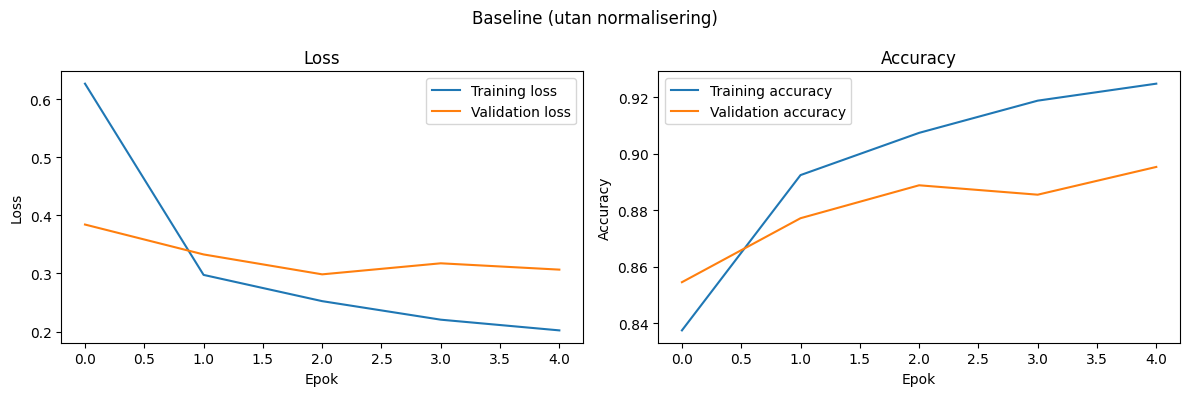

In [10]:
# Träningskurvor

def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12,4))

    #Loss
    plt.subplot(1,2,1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    #Accuracy
    plt.subplot(1,2,2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_base, title="Baseline (utan normalisering)")


Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

In [11]:
# Utvärdera på testdata

test_loss_base, test_accuracy_base = model_base.evaluate(X_test_base, y_test, verbose=0)

print(f"Test loss: {test_loss_base:.4f}")
print(f"Test accuracy: {test_accuracy_base:.4f}")

Test loss: 0.3408
Test accuracy: 0.8833


Testresultatet är något sämre än validation-resultatet. Detta är inte ovanligt och kan bero på att validation-setet kommer från samma ursprungliga träningsdata, medan test-setet består av helt osedda bilder.

Validation-resultatet kan därför vara något mer optimistiskt, eftersom modellen indirekt har använts för att övervaka och justera träningen utifrån denna data.

Skillnaden kan även bero på naturlig variation i datan, där testsetet kan innehålla exempel som är svårare att klassificera än validation-setet. Trots detta tyder resultaten på att modellen generaliserar relativt bra.

- Modell 2 (med normalisering)

Vi normaliserar våra pixelvärden. Vi delar alla pixelvärden med 255 så att dem hamnar mellan 0 och 1 istället.

In [12]:
# Normalisering
X_train_norm = X_train_base.astype("float32") / 255.0
X_val_norm = X_val_base.astype("float32") / 255.0
X_test_norm = X_test_base.astype("float32") / 255.0

# Kontrollera minsta och största värden efter normalisering
print("Minsta värde efter normalisering:", X_train_norm.min())
print("Största värde efter normalisering:", X_train_norm.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


In [13]:
model_norm = create_model()

history_norm = model_norm.fit(
    X_train_norm,
    y_train_base,
    validation_data=(X_val_norm, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.8281 - loss: 0.4758 - val_accuracy: 0.8645 - val_loss: 0.3721
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8876 - loss: 0.3160 - val_accuracy: 0.8948 - val_loss: 0.2969
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9024 - loss: 0.2687 - val_accuracy: 0.8998 - val_loss: 0.2735
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9140 - loss: 0.2358 - val_accuracy: 0.9070 - val_loss: 0.2534
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9241 - loss: 0.2097 - val_accuracy: 0.9120 - val_loss: 0.2393


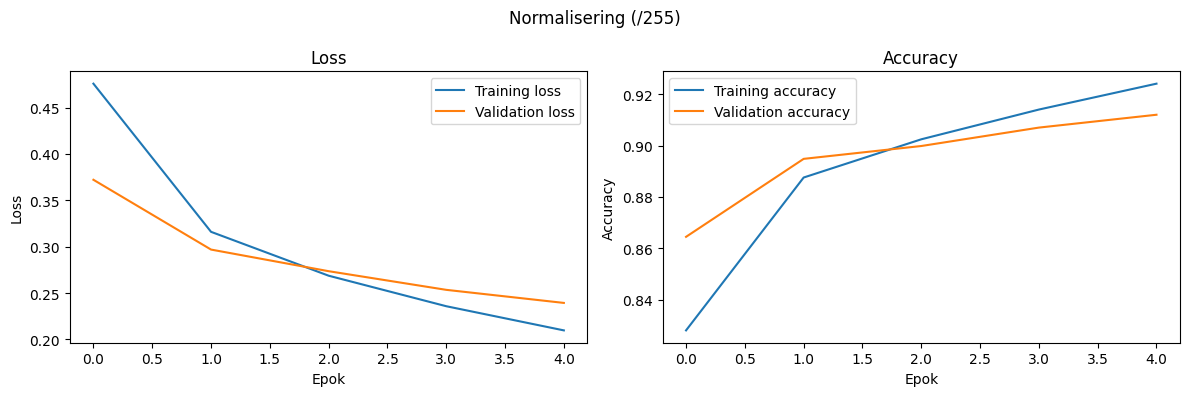

In [14]:
plot_history(history_norm, title="Normalisering (/255)")

Skillnaden mellan training accuracy och validation accuracy är relativt liten, vilket tyder på att modellen generaliserar ganska bra.

In [15]:
# Utvärdera på testdata

test_loss_norm, test_accuracy_norm = model_norm.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test loss (norm): {test_loss_norm:.4f}")
print(f"Test accuracy (norm): {test_accuracy_norm:.4f}")

Test loss (norm): 0.2762
Test accuracy (norm): 0.8971


- Modell 3 (med standardisering)

In [16]:
# Modell med standardisering
mean = X_train_base.mean()
std = X_train_base.std()

X_train_std = (X_train_base - mean) / std
X_val_std = (X_val_base - mean) / std
X_test_std = (X_test_base - mean) / std

In [17]:
model_std = create_model()

history_std = model_std.fit(
    X_train_std,
    y_train_base,
    validation_data=(X_val_std, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.8465 - loss: 0.4225 - val_accuracy: 0.8878 - val_loss: 0.3010
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8999 - loss: 0.2737 - val_accuracy: 0.9057 - val_loss: 0.2609
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9163 - loss: 0.2287 - val_accuracy: 0.9100 - val_loss: 0.2413
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9276 - loss: 0.1972 - val_accuracy: 0.9077 - val_loss: 0.2476
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9371 - loss: 0.1709 - val_accuracy: 0.9057 - val_loss: 0.2651


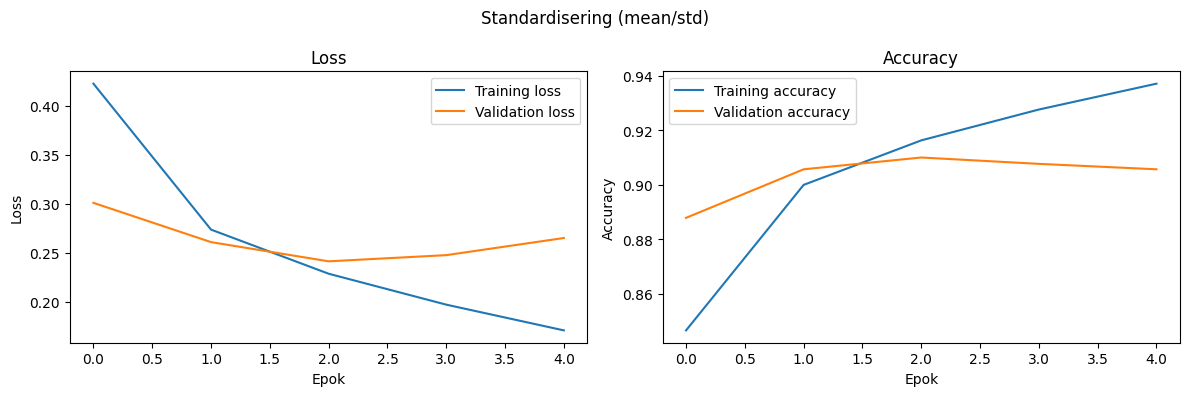

In [18]:
plot_history(history_std, title="Standardisering (mean/std)")

Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar i början, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

Efter några epoker börjar dock validation loss plana ut, medan training loss fortsätter att minska. Detta kan vara ett tidigt tecken på överanpassning (overfitting), där modellen lär sig träningsdatan för väl.

Skillnaden mellan training accuracy och validation accuracy är dock relativt liten, vilket tyder på att modellen fortfarande generaliserar ganska bra.

In [19]:
# Utvärdera på testdata

test_loss_std, test_accuracy_std = model_std.evaluate(
    X_test_std,
    y_test,
    verbose=0
)

print(f"Test loss (std): {test_loss_std:.4f}")
print(f"Test accuracy (std): {test_accuracy_std:.4f}")

Test loss (std): 0.3065
Test accuracy (std): 0.8967


Jämförelse

In [20]:
results = pd.DataFrame({
    "Experiment": ["Baseline", "Normalisering", "Standardisering"],
    "Test Accuracy": [test_accuracy_base, test_accuracy_norm, test_accuracy_std],
    "Test Loss": [test_loss_base, test_loss_norm, test_loss_std]
})

results

,Experiment,Test Accuracy,Test Loss
0,Baseline,0.8833,0.340763
1,Normalisering,0.8971,0.276188
2,Standardisering,0.8967,0.306546
